# Magnitude Schechter

In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
def absMag2lum(M, M_star):
    """Return the luminosity frome the absolute magnitude M and a reference  absolute magnitude M_sar."""
    return 10**(0.4 * (M_star - M))


def proba_schechter_mag(M, M_star, alpha):
    """Compute the relative probability of a magnitude M.
    M_star is the caracteristic magnitude of Schechter's luminosity function."""
    L_ratio = absMag2lum(M, M_star) #Conversion magnitude -> relative luminosity L/L*
    return (L_ratio**alpha) * np.exp(-L_ratio)


def generate_schechter_magnitudes(N, M_min=-23, M_max=-15, M_star=-20.44, alpha=-1.1):
    """Generate N randomized absolute magnitudes, by using a reject test and Schechter's law."""
    magnitudes = []
    while len(magnitudes) < N:
        M_test = np.random.uniform(M_min, M_max)
        p_test = np.random.uniform(0, 1) #Probability for rejet test
        if p_test < proba_schechter_mag(M_test, M_star, alpha): magnitudes.append(M_test)         
    return np.array(magnitudes)


def get_dL(zi, H0=67.4, Om=0.315, Ol=0.685, c=3e8):
    '''Compute the luminosity distance depending on the redshift z, the Hubble constant H0, the cosmological parameters Om and Ol, and the speed of ligt c.'''
    inv_Ez = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + Ol)
    integral, _ = quad(inv_Ez, 0, zi)
    return (c / H0) * (1 + zi) * integral


def generate_magLum(N, z_min=0.01, z_max=3.0, M_min=-23, M_max=-15, M_star=-20.44, alpha=-1.1, sigma_M_star=1.5, **kwargs):
    #Cosmological Parameters  (Planck 2018):
    H0 = kwargs.get('H0', 67.4)
    Om = kwargs.get('Om', 0.315)
    Ol = kwargs.get('Ol', 0.685)
    c = kwargs.get('c', 3e5) #speed of ligt in km/s (because H0 is in Km/s/Mpc)
    M_sun = kwargs.get('M_sun', 4.83) #Absolute magnitude of Sun
    
    z = np.random.uniform(z_min, z_max, N) #Redshift
    dL_mpc = np.array([get_dL(zi, H0, Om, Ol, c) for zi in z]) #luminosity distance in Mpc
    M = generate_schechter_magnitudes(N, M_min, M_max, M_star, alpha) #Absolute magnitudes
    m = M + 5*np.log10(dL_mpc) + 25 #Aparent magnitudes
    L = absMag2lum(M, M_sun) #luminosities
    return z, m, M, L, dL_mpc

In [3]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


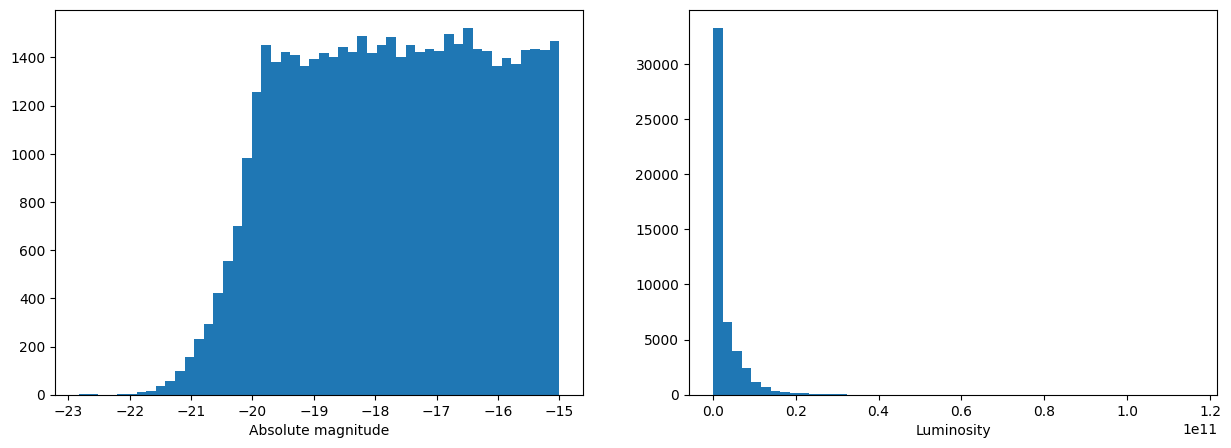

In [4]:
z, m, M, L, dL_mpc = generate_magLum(npix)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]));

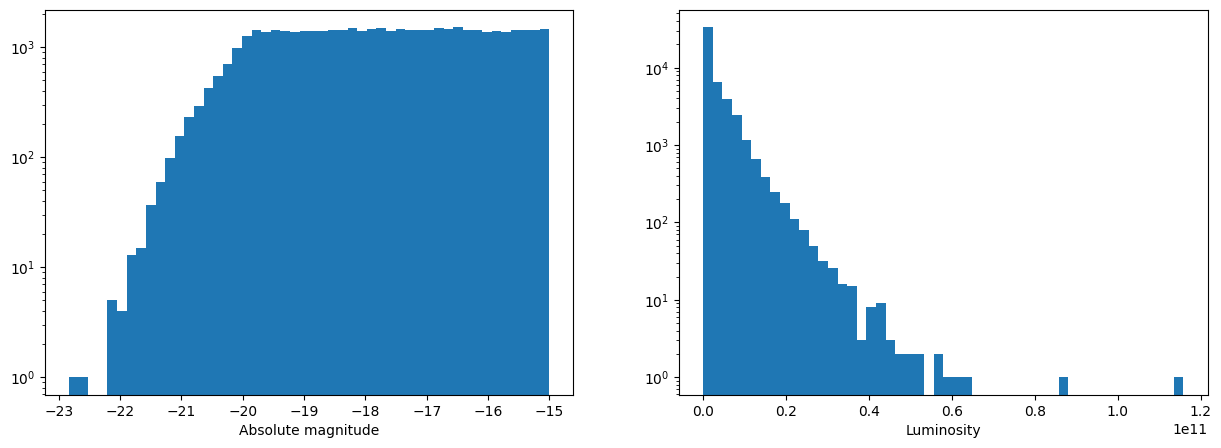

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_yscale('log');